# Centroid Classifier from Scratch
by AI@UCI

** ENSURE YOU ARE RUNNING THIS IN AN ENVIRONMENT WITH THE REQUIRED PACKAGES **

## Introduction to Centroid Classifier

The Centroid Classifier is a simple yet effective classification algorithm that:

- Calculates the centroid (mean) of each class in the training data
- Classifies new points by finding the nearest centroid
- Is computationally efficient and easy to understand
- Works well when classes are roughly spherical and well-separated

We'll implement:
- Centroid calculation for each class
- Distance-based classification
- Visualization of centroids and decision boundaries


In [1]:
! pip install numpy pandas matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product


## Loading the Iris Dataset


In [3]:
# Load the iris dataset
IRIS_CSV = "../datasets/centroid_iris_dataset.csv"
df = pd.read_csv(IRIS_CSV)
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# Convert species names to numeric labels and separate features
species_to_int = {s: i for i, s in enumerate(sorted(df["species"].unique()))}
int_to_species = {v: k for k, v in species_to_int.items()}
y = df["species"].map(species_to_int).values.astype(int)
X = df.drop(columns=["species"]).values.astype(float)

print("Dataset shape:", df.shape)
print("Features shape:", X.shape)
print("Target classes:", df['species'].unique())


Dataset shape: (150, 5)
Features shape: (150, 4)
Target classes: ['setosa' 'versicolor' 'virginica']


## Centroid Classifier Implementation


In [5]:
class CentroidClassifier:
    def __init__(self):
        """Initialize Centroid Classifier."""
        self.centroids = None
        self.classes = None

    def fit(self, X, y):
        """Calculate centroids for each class."""
        self.classes = np.unique(y)
        self.centroids = {}
        
        for cls in self.classes:
            mask = y == cls
            self.centroids[cls] = np.mean(X[mask], axis=0)

    def _euclidean(self, a, b):
        """Calculate Euclidean distance between points a and b."""
        return np.sqrt(np.sum((a - b) ** 2))

    def _predict_one(self, x):
        """Predict the class for a single data point."""
        distances = {}
        for cls, centroid in self.centroids.items():
            distances[cls] = self._euclidean(x, centroid)
        return min(distances, key=distances.get)

    def predict(self, X):
        """Predict classes for multiple data points."""
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x) for x in X], dtype=int)

    def score(self, X, y):
        """Calculate accuracy score."""
        preds = self.predict(X)
        return float(np.mean(preds == y))


In [6]:
# Simple train-test split
np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
train_idx, test_idx = indices[:train_size], indices[train_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 120 samples
Test set: 30 samples


In [7]:
# Train and test the Centroid Classifier
centroid_clf = CentroidClassifier()
centroid_clf.fit(X_train, y_train)

accuracy = centroid_clf.score(X_test, y_test)
print(f"Test accuracy: {accuracy:.3f}")

# Display centroids
print("\nCentroids for each class:")
for cls, centroid in centroid_clf.centroids.items():
    print(f"{int_to_species[cls]}: {centroid}")


Test accuracy: 0.900

Centroids for each class:
setosa: [4.98604651 3.43488372 1.46744186 0.24651163]
versicolor: [5.92051282 2.77179487 4.26410256 1.33846154]
virginica: [6.60789474 2.97631579 5.55       2.04736842]


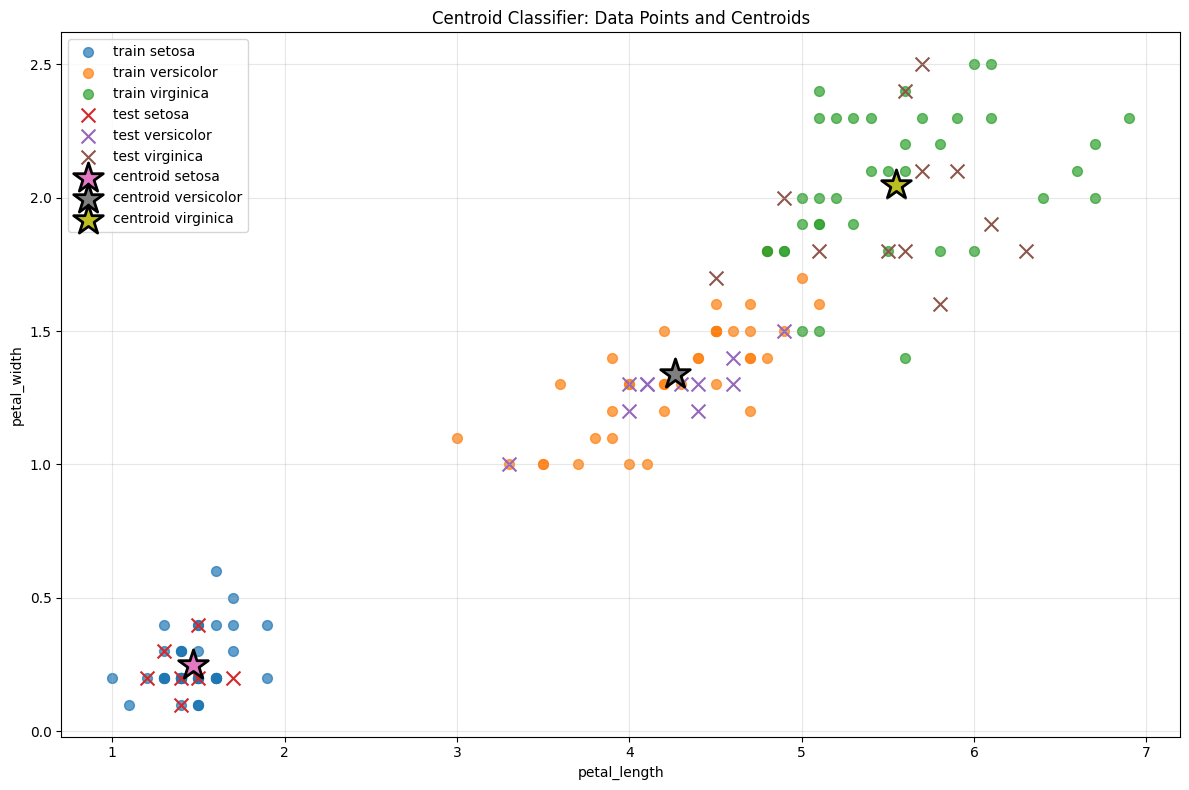

In [8]:
# Visualize centroids and data points (using petal features for 2D)
plt.figure(figsize=(12, 8))

# Plot training data
for cls in np.unique(y_train):
    mask = y_train == cls
    plt.scatter(X_train[mask, 2], X_train[mask, 3], 
               label=f"train {int_to_species[cls]}", s=50, alpha=0.7)

# Plot test data
for cls in np.unique(y_test):
    mask = y_test == cls
    plt.scatter(X_test[mask, 2], X_test[mask, 3], 
               marker="x", label=f"test {int_to_species[cls]}", s=100)

# Plot centroids
for cls, centroid in centroid_clf.centroids.items():
    plt.scatter(centroid[2], centroid[3], 
               marker="*", s=500, label=f"centroid {int_to_species[cls]}", 
               edgecolors='black', linewidth=2)

plt.xlabel("petal_length")
plt.ylabel("petal_width")
plt.title("Centroid Classifier: Data Points and Centroids")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
